In [ ]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [67]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    message: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [68]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [69]:
from langchain_ollama import OllamaLLM

# Initialize Ollama LLM
# Make sure Ollama is running locally (ollama serve)
# This model is installed locally: ollama list
llm = OllamaLLM(model="llama3.2", temperature=0.7)

In [70]:
llm

OllamaLLM(metadata={'lc_versions': {'langchain-core': '1.6.0', 'langchain': '1.3.16'}}, model='llama3.2', temperature=0.7)

In [71]:
def chatbot(state: State) -> State:
    return {"message": [llm.invoke(state["message"])]}


In [72]:
graph_builder=StateGraph(State)
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)
graph = graph_builder.compile()



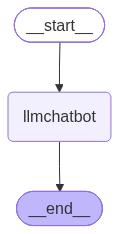

In [73]:
from IPython.display import Image, display

try:
    png_data = graph.get_graph().draw_mermaid_png()
    display(Image(png_data))
except Exception as e:
    print("Error:", e)


In [ ]:
response = graph.invoke({"message": ["Hello, how are you?"]})
print(response["message"][-1])

ResponseError: error starting llama-server: llama-server binary not found (checked: C:\Users\sibta\AppData\Local\Programs\Ollama\llama-server.exe, C:\Users\sibta\AppData\Local\Programs\Ollama\lib\ollama\llama-server.exe, C:\Users\sibta\AppData\Local\Programs\lib\ollama\llama-server.exe, C:\Users\sibta\AppData\Local\Programs\Ollama\build\lib\ollama\llama-server.exe, C:\Users\sibta\AppData\Local\Programs\Ollama\dist\windows-amd64\lib\ollama\llama-server.exe, C:\Users\sibta\AppData\Local\Programs\Ollama\dist\windows_amd64\lib\ollama\llama-server.exe). Run 'cmake -S llama/server --preset cpu && cmake --build --preset cpu' first  (status code: 500)

: 